In [1]:
# src/ on the path - cwd is notebooks/
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [4]:
import prepare

canopy, landcover = prepare.align_labels()

canopy fraction: 0.268


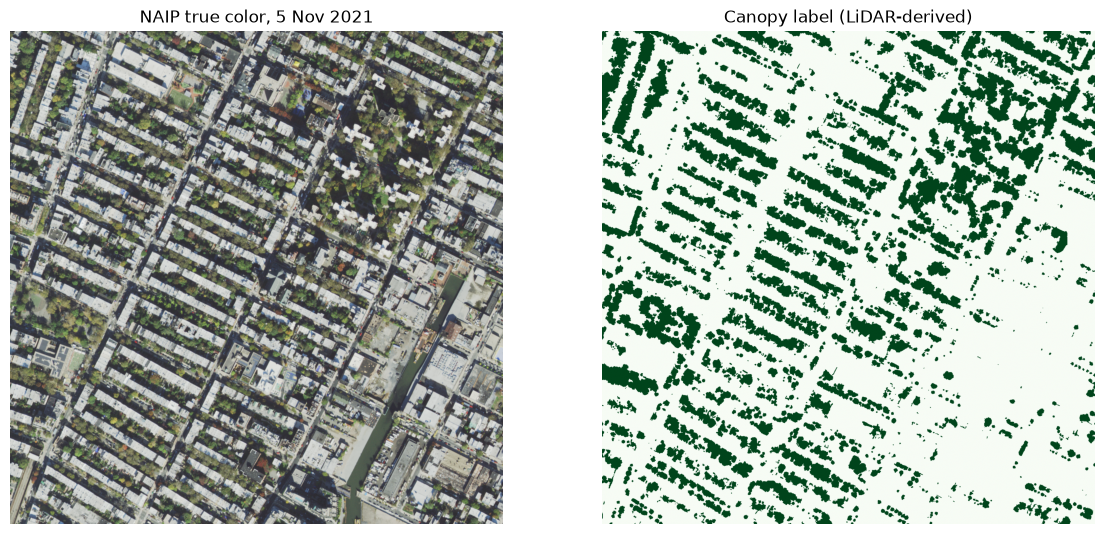

In [11]:
with rasterio.open(config.NAIP) as naip:
    rgb = naip.read([1, 2, 3], window=config.AOI)[:, :1500, :1500]

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(np.transpose(rgb, (1, 2, 0)))   # rasterio is (band, row, col)
ax[0].set_title("NAIP true color, 5 Nov 2021")
ax[1].imshow(canopy[:1500, :1500], cmap="Greens")
ax[1].set_title("Canopy label (LiDAR-derived)")
for a in ax:
    a.axis("off")

plt.savefig(config.FIGURES / "01_alignment_check.png", dpi=120, bbox_inches="tight")
plt.show()

NAIP imagery and canopy label data appear to show alignment, however, some canopy on the later dated satellite imagery is chaning color. This may affect NDVI values.

In [6]:
prepare.cut_chips(landcover)

1024 chips written, 0 skipped
